# 11 — Análisis operativo de los modelos finales

Este notebook reconstruye las configuraciónes cerradas de Logistic Regression, XGBoost y MLP, genera probabilidades sobre el holdout temporal de 2017 y compara su capacidad para priorizar cancelaciones críticas. No realiza nuevas busquedas ni uútiliza 2017 para modificar features o hiperparámetros.

La primera etapa se limita a ordenación, capacidad operativa y valor bruto capturado. `ADR x noches` no se interpreta como pérdida y todavía no se calculan ahorros.


## Imports y resolución de la raíz


In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)


In [2]:
def find_project_root(start_path=None):
    current = Path(start_path or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del proyecto.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Raíz del proyecto: {PROJECT_ROOT}")


Raíz del proyecto: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026


In [3]:
from src.config import RANDOM_STATE, RAW_DATA_DIR
from src.data import (
    combine_hotel_datasets,
    load_csv_with_fallback,
    make_temporal_holdout_split,
    normalize_text_values,
)
from src.features import (
    build_base_feature_set,
    build_logistic_second_batch_candidate_set,
    build_tree_model_feature_sets,
    get_feature_types,
)
from src.preprocessing import build_tabular_preprocessor


## Carga, integración y división temporal


In [4]:
H1_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H1.csv"
H2_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H2.csv"

h1_df = load_csv_with_fallback(RAW_DATA_DIR / "H1.csv", H1_URL)
h2_df = load_csv_with_fallback(RAW_DATA_DIR / "H2.csv", H2_URL)
bookings_df = normalize_text_values(combine_hotel_datasets(h1_df, h2_df))
X_reference, y = build_base_feature_set(bookings_df)

X_reference_train, X_reference_holdout, y_train, y_holdout = make_temporal_holdout_split(
    X_reference,
    y,
    period_values=X_reference["ArrivalDateYear"],
    validation_period=2017,
)

if not X_reference_holdout.index.is_unique:
    raise ValueError("El indice del holdout debe ser unico para unir las probabilidades.")

display(pd.DataFrame([{
    "development_rows": len(X_reference_train),
    "holdout_rows": len(X_reference_holdout),
    "development_cancellation_rate": y_train.mean(),
    "holdout_cancellation_rate": y_holdout.mean(),
}]))


,development_rows,holdout_rows,development_cancellation_rate,holdout_cancellation_rate
0,78703,40687,0.361854,0.386979


## Conjuntos cerrados de variables

Logistic Regression uútiliza su conjunto lineal engineered. XGBoost y MLP uútilizan la poda de 17 variables. Las filas y el holdout son idénticos; solamente cambia la representación uútilizada por cada familia.


In [5]:
logistic_features = build_logistic_second_batch_candidate_set(X_reference)
tree_feature_sets = build_tree_model_feature_sets(X_reference)
TREE_PRUNED_SET_NAME = "Tree-pruned | 17 features"
tree_pruned_features = tree_feature_sets[TREE_PRUNED_SET_NAME]

model_feature_sets = {
    "Logistic Regression": {
        "train": logistic_features.loc[X_reference_train.index].copy(),
        "holdout": logistic_features.loc[X_reference_holdout.index].copy(),
    },
    "XGBoost": {
        "train": tree_pruned_features.loc[X_reference_train.index].copy(),
        "holdout": tree_pruned_features.loc[X_reference_holdout.index].copy(),
    },
    "MLP": {
        "train": tree_pruned_features.loc[X_reference_train.index].copy(),
        "holdout": tree_pruned_features.loc[X_reference_holdout.index].copy(),
    },
}

display(pd.DataFrame([
    {
        "model": model_name,
        "feature_count": sets["train"].shape[1],
        "development_rows": len(sets["train"]),
        "holdout_rows": len(sets["holdout"]),
    }
    for model_name, sets in model_feature_sets.items()
]))


,model,feature_count,development_rows,holdout_rows
0,Logistic Regression,26,78703,40687
1,XGBoost,17,78703,40687
2,MLP,17,78703,40687


## Reconstrucción de los tres modelos finales

Estas funciónes contienen únicamente las configuraciónes ya selecciónadas. No ejecutan Grid Search ni consultan resultados de 2017 para cambiar parámetros. `scale_pos_weight` de XGBoost se calcula solamente con las clases de desarrollo.


In [6]:
def build_logistic_final_pipeline(X):
    numeric_features, categorical_features = get_feature_types(
        X, require_all_categorical=False
    )
    preprocessor = build_tabular_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        scale_numeric=True,
    )
    model = LogisticRegression(
        C=1.0,
        class_weight="balanced",
        l1_ratio=1.0,
        solver="liblinear",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )
    return Pipeline([("preprocessor", preprocessor), ("model", model)])


def build_xgboost_final_pipeline(X, y_development):
    numeric_features, categorical_features = get_feature_types(
        X, require_all_categorical=False
    )
    preprocessor = build_tabular_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        scale_numeric=False,
    )
    negative_count = y_development.eq(0).sum()
    positive_count = y_development.eq(1).sum()
    model = XGBClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=7,
        min_child_weight=15,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=5.0,
        scale_pos_weight=negative_count / positive_count,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        n_jobs=1,
        random_state=RANDOM_STATE,
    )
    return Pipeline([("preprocessor", preprocessor), ("model", model)])


def build_mlp_final_pipeline(X):
    numeric_features, categorical_features = get_feature_types(
        X, require_all_categorical=False
    )
    preprocessor = build_tabular_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        scale_numeric=True,
    )
    model = MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        alpha=0.01,
        batch_size=64,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        tol=1e-4,
        random_state=RANDOM_STATE,
    )
    return Pipeline([("preprocessor", preprocessor), ("model", model)])


final_models = {
    "Logistic Regression": build_logistic_final_pipeline(
        model_feature_sets["Logistic Regression"]["train"]
    ),
    "XGBoost": build_xgboost_final_pipeline(
        model_feature_sets["XGBoost"]["train"], y_train
    ),
    "MLP": build_mlp_final_pipeline(model_feature_sets["MLP"]["train"]),
}


## Reentrenamiento fijo y generación de probabilidades

Cada pipeline se ajusta una vez sobre todo 2015–2016. Las probabilidades se calculan sobre las mismás 40.687 reservas de 2017 y se conservan por índice para la evaluación operativa.


In [7]:
model_probabilities = pd.DataFrame(index=X_reference_holdout.index)
training_records = []

for model_name, model in final_models.items():
    X_model_train = model_feature_sets[model_name]["train"]
    X_model_holdout = model_feature_sets[model_name]["holdout"]
    start = time.perf_counter()
    model.fit(X_model_train, y_train)
    probabilities = model.predict_proba(X_model_holdout)[:, 1]
    elapsed = time.perf_counter() - start
    probability_column = {
        "Logistic Regression": "LogisticProbability",
        "XGBoost": "XGBoostProbability",
        "MLP": "MLPProbability",
    }[model_name]
    model_probabilities[probability_column] = probabilities
    record = {
        "model": model_name,
        "fit_and_predict_seconds": elapsed,
        "minimum_probability": probabilities.min(),
        "mean_probability": probabilities.mean(),
        "maximum_probability": probabilities.max(),
    }
    if model_name == "MLP":
        record["epochs"] = model.named_steps["model"].n_iter_
    training_records.append(record)
    print(f"{model_name}: {elapsed:.2f} segundos")

training_summary = pd.DataFrame(training_records)
display(training_summary)


Logistic Regression: 12.81 segundos
XGBoost: 2.12 segundos
MLP: 28.72 segundos


,model,fit_and_predict_seconds,minimum_probability,mean_probability,maximum_probability,epochs
0,Logistic Regression,12.812797,2.302159e-36,0.534847,0.999867,NaN
1,XGBoost,2.122937,4.845381e-04,0.396799,0.998011,NaN
2,MLP,28.720100,1.166443e-45,0.669555,1.000000,55.0


## Construcción retrospectiva de eventos críticos

`ReservationStatus` y `ReservationStatusDate` se uútilizan solo después de predecir. Un evento crítico es un `No-Show` o una cancelación registrada entre cero y siete días antes de la llegada. Se mantienen columnas separadas para analizar ambos tipos.


In [8]:
LATE_CANCELLATION_DAYS = 7
MONTH_TO_NUMBER = {
    month: number
    for number, month in enumerate([
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
    ], start=1)
}

operational_holdout = bookings_df.loc[X_reference_holdout.index, [
    "ReservationStatus", "ReservationStatusDate", "ADR",
    "ArrivalDateYear", "ArrivalDateMonth", "ArrivalDateDayOfMonth",
    "StaysInWeekendNights", "StaysInWeekNights",
]].copy()
operational_holdout["ActualCancellation"] = y_holdout.astype("int8")
operational_holdout = operational_holdout.join(model_probabilities)

arrival_month_number = operational_holdout["ArrivalDateMonth"].map(MONTH_TO_NUMBER)
if arrival_month_number.isna().any():
    unknown_months = operational_holdout.loc[
        arrival_month_number.isna(), "ArrivalDateMonth"
    ].unique()
    raise ValueError(f"Meses no reconocidos: {unknown_months}")

operational_holdout["ArrivalDate"] = pd.to_datetime({
    "year": operational_holdout["ArrivalDateYear"],
    "month": arrival_month_number,
    "day": operational_holdout["ArrivalDateDayOfMonth"],
})
operational_holdout["StatusDate"] = pd.to_datetime(
    operational_holdout["ReservationStatusDate"]
)
operational_holdout["DaysBeforeArrival"] = (
    operational_holdout["ArrivalDate"] - operational_holdout["StatusDate"]
).dt.days

operational_holdout["IsNoShow"] = operational_holdout[
    "ReservationStatus"
].eq("No-Show")
operational_holdout["IsLateCancellation"] = (
    operational_holdout["ReservationStatus"].eq("Canceled")
    & operational_holdout["DaysBeforeArrival"].between(0, LATE_CANCELLATION_DAYS)
)
operational_holdout["IsCriticalCancellation"] = (
    operational_holdout["IsNoShow"]
    | operational_holdout["IsLateCancellation"]
)
operational_holdout["CriticalEventType"] = np.select(
    [operational_holdout["IsNoShow"], operational_holdout["IsLateCancellation"]],
    ["No-Show", "Late cancellation (0-7 days)"],
    default="Non-critical",
)


## Valor bruto expuesto

`GrossBookingValue = ADR x TotalNights` apróxima el ingreso bruto asociado con la estadía. No es una pérdida contable. El ADR negativo y el registro con ADR 5400 se excluyen solamente de las sumás de valor; permanecen en todas las métricas de eventos.


In [9]:
operational_holdout["TotalNights"] = (
    operational_holdout["StaysInWeekendNights"]
    + operational_holdout["StaysInWeekNights"]
)
operational_holdout["GrossValueEligible"] = (
    operational_holdout["ADR"].ge(0)
    & operational_holdout["ADR"].ne(5400)
)
operational_holdout["GrossBookingValue"] = np.where(
    operational_holdout["GrossValueEligible"],
    operational_holdout["ADR"] * operational_holdout["TotalNights"],
    np.nan,
)

event_profile = operational_holdout.groupby(
    "CriticalEventType", observed=True
).agg(
    reservations=("ActualCancellation", "size"),
    actual_cancellations=("ActualCancellation", "sum"),
    gross_booking_value=("GrossBookingValue", "sum"),
).reset_index()

critical_total = int(operational_holdout["IsCriticalCancellation"].sum())
no_show_total = int(operational_holdout["IsNoShow"].sum())
late_cancellation_total = int(operational_holdout["IsLateCancellation"].sum())
critical_gross_value = operational_holdout.loc[
    operational_holdout["IsCriticalCancellation"], "GrossBookingValue"
].sum()

display(event_profile)
print(f"Eventos críticos: {critical_total}")
print(f"No-Show: {no_show_total}")
print(f"Cancelaciones tardías: {late_cancellation_total}")
print(f"Valor bruto crítico elegible: {critical_gross_value:.2f}")


,CriticalEventType,reservations,actual_cancellations,gross_booking_value
0,Late cancellation (0-7 days),1250,1250,419174.36
1,No-Show,348,348,120924.26
2,Non-critical,39089,14147,16494744.95


Eventos críticos: 1598
No-Show: 348
Cancelaciones tardías: 1250
Valor bruto crítico elegible: 540098.62


## Comparación a igual capacidad operativa

Para cada modelo se ordenan las reservas por probabilidad y se seleccióna exactamente el top 5, 10, 20 y 30 por ciento. Esta política compara ranking, no calibracion. Cuando existen empates en el límite, se conserva el orden estable del índice para intervenir exactamente la capacidad indicada.


In [10]:
CAPACITY_RATES = [0.05, 0.10, 0.20, 0.30]
MODEL_PROBABILITY_COLUMNS = {
    "Logistic Regression": "LogisticProbability",
    "XGBoost": "XGBoostProbability",
    "MLP": "MLPProbability",
}


def summarize_policy(frame, selected_mask, model_name, policy, policy_value):
    selected_mask = pd.Series(selected_mask, index=frame.index).astype(bool)
    interventions = int(selected_mask.sum())
    actual_intervention_rate = interventions / len(frame)
    actual_cancellation_mask = frame["ActualCancellation"].eq(1)
    critical_mask = frame["IsCriticalCancellation"]
    no_show_mask = frame["IsNoShow"]
    late_mask = frame["IsLateCancellation"]
    detected_critical = selected_mask & critical_mask
    selected_value = frame.loc[detected_critical, "GrossBookingValue"].sum()

    return {
        "model": model_name,
        "policy": policy,
        "policy_value": policy_value,
        "interventions": interventions,
        "intervention_rate": actual_intervention_rate,
        "cancellation_precision": (
            (selected_mask & actual_cancellation_mask).sum() / interventions
            if interventions else np.nan
        ),
        "cancellation_recall": (
            (selected_mask & actual_cancellation_mask).sum()
            / actual_cancellation_mask.sum()
        ),
        "critical_events_detected": int(detected_critical.sum()),
        "critical_precision": detected_critical.sum() / interventions if interventions else np.nan,
        "critical_recall": detected_critical.sum() / critical_mask.sum(),
        "lift_vs_random": (
            (detected_critical.sum() / critical_mask.sum()) / actual_intervention_rate
            if actual_intervention_rate else np.nan
        ),
        "no_show_recall": (selected_mask & no_show_mask).sum() / no_show_mask.sum(),
        "late_cancellation_recall": (selected_mask & late_mask).sum() / late_mask.sum(),
        "critical_gross_value_captured": selected_value,
        "critical_gross_value_capture_rate": selected_value / critical_gross_value,
    }


In [11]:
capacity_rows = []
for model_name, probability_column in MODEL_PROBABILITY_COLUMNS.items():
    scores = operational_holdout[probability_column]
    for capacity_rate in CAPACITY_RATES:
        intervention_count = int(np.ceil(capacity_rate * len(operational_holdout)))
        selected_indices = scores.nlargest(intervention_count, keep="first").index
        selected_mask = operational_holdout.index.isin(selected_indices)
        capacity_rows.append(summarize_policy(
            operational_holdout,
            selected_mask,
            model_name=model_name,
            policy="Top capacity",
            policy_value=capacity_rate,
        ))

capacity_results = pd.DataFrame(capacity_rows)
display(capacity_results.round(4))


,model,policy,policy_value,interventions,intervention_rate,cancellation_precision,cancellation_recall,critical_events_detected,critical_precision,critical_recall,lift_vs_random,no_show_recall,late_cancellation_recall,critical_gross_value_captured,critical_gross_value_capture_rate
0,Logistic Regression,Top capacity,0.05,2035,0.05,0.9287,0.1200,68,0.0334,0.0426,0.8508,0.0517,0.0400,44061.15,0.0816
1,Logistic Regression,Top capacity,0.10,4069,0.10,0.9211,0.2380,115,0.0283,0.0720,0.7196,0.0805,0.0696,61719.09,0.1143
2,Logistic Regression,Top capacity,0.20,8138,0.20,0.8401,0.4342,332,0.0408,0.2078,1.0387,0.3420,0.1704,140406.02,0.2600
3,Logistic Regression,Top capacity,0.30,12207,0.30,0.7739,0.6000,520,0.0426,0.3254,1.0846,0.4770,0.2832,208977.57,0.3869
4,XGBoost,Top capacity,0.05,2035,0.05,0.9990,0.1291,4,0.0020,0.0025,0.0500,0.0000,0.0032,9058.25,0.0168
5,XGBoost,Top capacity,0.10,4069,0.10,0.9813,0.2536,57,0.0140,0.0357,0.3567,0.0776,0.0240,34970.29,0.0647
6,XGBoost,Top capacity,0.20,8138,0.20,0.8564,0.4426,190,0.0233,0.1189,0.5944,0.1983,0.0968,103665.61,0.1919
7,XGBoost,Top capacity,0.30,12207,0.30,0.7744,0.6004,441,0.0361,0.2760,0.9198,0.4138,0.2376,183517.51,0.3398
8,MLP,Top capacity,0.05,2035,0.05,0.9744,0.1259,15,0.0074,0.0094,0.1877,0.0057,0.0104,26882.69,0.0498
9,MLP,Top capacity,0.10,4069,0.10,0.9312,0.2406,56,0.0138,0.0350,0.3504,0.0287,0.0368,50645.40,0.0938


## Referencia de selección aleatoria

Una selección aleatoria con la misma capacidad captura en expectativa la misma proporción de eventos y valor bruto que la proporción intervenida. Su lift es uno. Las cantidades esperadas pueden ser fraccionarias porque no representan una simulación particular, sino el promedio teórico.


In [12]:
random_rows = []
critical_prevalence = critical_total / len(operational_holdout)
for capacity_rate in CAPACITY_RATES:
    intervention_count = int(np.ceil(capacity_rate * len(operational_holdout)))
    actual_rate = intervention_count / len(operational_holdout)
    random_rows.append({
        "model": "Random selection (expected)",
        "policy": "Top capacity",
        "policy_value": capacity_rate,
        "interventions": intervention_count,
        "intervention_rate": actual_rate,
        "cancellation_precision": y_holdout.mean(),
        "cancellation_recall": actual_rate,
        "critical_events_detected": critical_total * actual_rate,
        "critical_precision": critical_prevalence,
        "critical_recall": actual_rate,
        "lift_vs_random": 1.0,
        "no_show_recall": actual_rate,
        "late_cancellation_recall": actual_rate,
        "critical_gross_value_captured": critical_gross_value * actual_rate,
        "critical_gross_value_capture_rate": actual_rate,
    })

random_results = pd.DataFrame(random_rows)
capacity_comparison = pd.concat(
    [capacity_results, random_results], ignore_index=True
)
display(capacity_comparison.round(4))


,model,policy,policy_value,interventions,intervention_rate,cancellation_precision,cancellation_recall,critical_events_detected,critical_precision,critical_recall,lift_vs_random,no_show_recall,late_cancellation_recall,critical_gross_value_captured,critical_gross_value_capture_rate
0,Logistic Regression,Top capacity,0.05,2035,0.05,0.9287,0.1200,68.0000,0.0334,0.0426,0.8508,0.0517,0.0400,44061.1500,0.0816
1,Logistic Regression,Top capacity,0.10,4069,0.10,0.9211,0.2380,115.0000,0.0283,0.0720,0.7196,0.0805,0.0696,61719.0900,0.1143
2,Logistic Regression,Top capacity,0.20,8138,0.20,0.8401,0.4342,332.0000,0.0408,0.2078,1.0387,0.3420,0.1704,140406.0200,0.2600
3,Logistic Regression,Top capacity,0.30,12207,0.30,0.7739,0.6000,520.0000,0.0426,0.3254,1.0846,0.4770,0.2832,208977.5700,0.3869
4,XGBoost,Top capacity,0.05,2035,0.05,0.9990,0.1291,4.0000,0.0020,0.0025,0.0500,0.0000,0.0032,9058.2500,0.0168
5,XGBoost,Top capacity,0.10,4069,0.10,0.9813,0.2536,57.0000,0.0140,0.0357,0.3567,0.0776,0.0240,34970.2900,0.0647
6,XGBoost,Top capacity,0.20,8138,0.20,0.8564,0.4426,190.0000,0.0233,0.1189,0.5944,0.1983,0.0968,103665.6100,0.1919
7,XGBoost,Top capacity,0.30,12207,0.30,0.7744,0.6004,441.0000,0.0361,0.2760,0.9198,0.4138,0.2376,183517.5100,0.3398
8,MLP,Top capacity,0.05,2035,0.05,0.9744,0.1259,15.0000,0.0074,0.0094,0.1877,0.0057,0.0104,26882.6900,0.0498
9,MLP,Top capacity,0.10,4069,0.10,0.9312,0.2406,56.0000,0.0138,0.0350,0.3504,0.0287,0.0368,50645.4000,0.0938


## Threshold 0,5 como referencia secundaria

El umbral 0,5 produce cantidades de intervenciónes diferentes y no constituye una comparación justa de capacidad. Se conserva para relacionar este análisis con las matrices de confusion de los notebooks de modelos.


In [13]:
threshold_rows = []
for model_name, probability_column in MODEL_PROBABILITY_COLUMNS.items():
    selected_mask = operational_holdout[probability_column].ge(0.5)
    threshold_rows.append(summarize_policy(
        operational_holdout,
        selected_mask,
        model_name=model_name,
        policy="Probability threshold",
        policy_value=0.5,
    ))

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results.round(4))


,model,policy,policy_value,interventions,intervention_rate,cancellation_precision,cancellation_recall,critical_events_detected,critical_precision,critical_recall,lift_vs_random,no_show_recall,late_cancellation_recall,critical_gross_value_captured,critical_gross_value_capture_rate
0,Logistic Regression,Probability threshold,0.5,21311,0.5238,0.6203,0.8396,1021,0.0479,0.6389,1.2198,0.7184,0.6168,380504.79,0.7045
1,XGBoost,Probability threshold,0.5,14452,0.3552,0.7375,0.6769,614,0.0425,0.3842,1.0817,0.4943,0.3536,243049.79,0.4500
2,MLP,Probability threshold,0.5,29796,0.7323,0.5096,0.9644,1297,0.0435,0.8116,1.1083,0.8592,0.7984,486318.14,0.9004


## Curvas de captura por capacidad


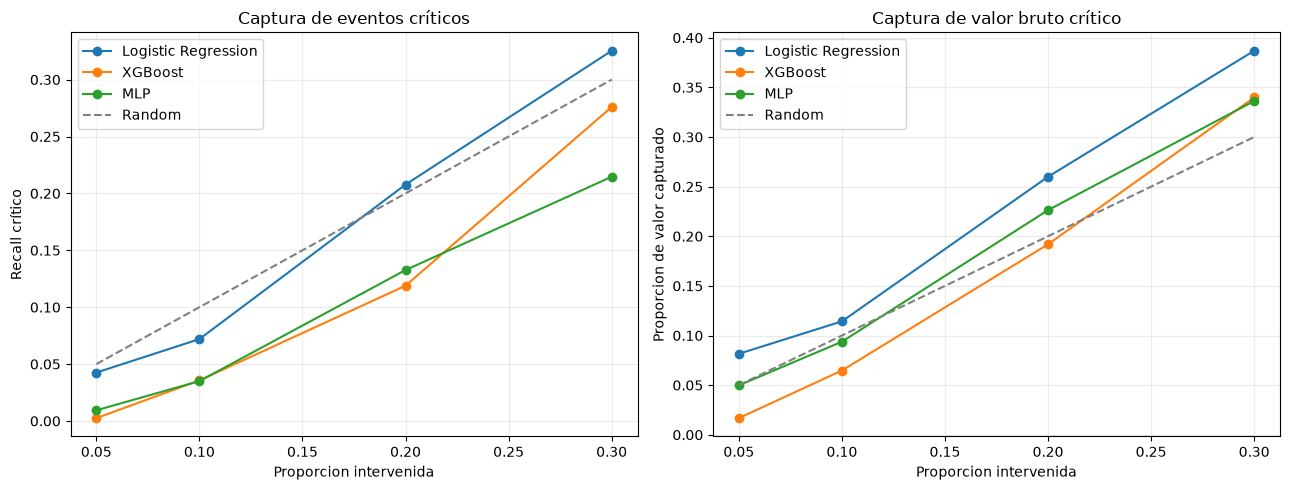

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model_name in MODEL_PROBABILITY_COLUMNS:
    model_rows = capacity_results.loc[capacity_results["model"].eq(model_name)]
    axes[0].plot(
        model_rows["intervention_rate"],
        model_rows["critical_recall"],
        marker="o",
        label=model_name,
    )
    axes[1].plot(
        model_rows["intervention_rate"],
        model_rows["critical_gross_value_capture_rate"],
        marker="o",
        label=model_name,
    )

random_rates = random_results["intervention_rate"]
axes[0].plot(random_rates, random_rates, linestyle="--", color="grey", label="Random")
axes[1].plot(random_rates, random_rates, linestyle="--", color="grey", label="Random")

axes[0].set_title("Captura de eventos críticos")
axes[0].set_xlabel("Proporcion intervenida")
axes[0].set_ylabel("Recall crítico")
axes[1].set_title("Captura de valor bruto crítico")
axes[1].set_xlabel("Proporcion intervenida")
axes[1].set_ylabel("Proporcion de valor capturado")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()


## Hallazgo operativo preliminar

Los modelos ordenan correctamente el target original de cancelación general, pero los primeros tramos del ranking no concentran cancelaciones críticas. XGBoost muestra con especial claridad esta diferencia: presenta la mejor ordenación de cancelaciones generales y una captura crítica inferior a la selección aleatoria en capacidades pequeñas.

El proyecto mantendrá `Cancelled` como objetivo original. El análisis económico evaluará honestamente la utilidad limitada de estos scores para eventos críticos y propondrá como trabajo futuro entrenar un modelo específico con `IsCriticalCancellation` como target. Antes de construir escenarios monetarios se agrega el siguiente diagnóstico de distribuciones y ROC AUC retrospectivo.


## Diagnóstico de scores por tipo de resultado

Se separan cuatro grupos retrospectivos: reservas no canceladas, cancelaciones no críticas, cancelaciones tardías y No-Show. Este bloque no cambia modelos ni targets; sirve para comprender en qué parte del ranking quedan los eventos económicamente más sensibles.


In [15]:
OUTCOME_ORDER = [
    "Not canceled",
    "Non-critical cancellation",
    "Late cancellation (0-7 days)",
    "No-Show",
]

operational_holdout["OperationalOutcome"] = np.select(
    [
        operational_holdout["IsNoShow"],
        operational_holdout["IsLateCancellation"],
        operational_holdout["ActualCancellation"].eq(1),
    ],
    [
        "No-Show",
        "Late cancellation (0-7 days)",
        "Non-critical cancellation",
    ],
    default="Not canceled",
)

outcome_counts = (
    operational_holdout["OperationalOutcome"]
    .value_counts()
    .reindex(OUTCOME_ORDER)
    .rename_axis("outcome")
    .reset_index(name="reservations")
)
display(outcome_counts)


,outcome,reservations
0,Not canceled,24942
1,Non-critical cancellation,14147
2,Late cancellation (0-7 days),1250
3,No-Show,348


In [16]:
score_distribution_rows = []
for model_name, probability_column in MODEL_PROBABILITY_COLUMNS.items():
    risk_percentile = operational_holdout[probability_column].rank(
        method="average", pct=True
    )
    for outcome in OUTCOME_ORDER:
        outcome_mask = operational_holdout["OperationalOutcome"].eq(outcome)
        scores = operational_holdout.loc[outcome_mask, probability_column]
        percentiles = risk_percentile.loc[outcome_mask]
        score_distribution_rows.append({
            "model": model_name,
            "outcome": outcome,
            "reservations": int(outcome_mask.sum()),
            "mean_score": scores.mean(),
            "median_score": scores.median(),
            "score_q25": scores.quantile(0.25),
            "score_q75": scores.quantile(0.75),
            "mean_risk_percentile": percentiles.mean(),
            "median_risk_percentile": percentiles.median(),
        })

score_distribution_summary = pd.DataFrame(score_distribution_rows)
display(score_distribution_summary.round(4))


,model,outcome,reservations,mean_score,median_score,score_q25,score_q75,mean_risk_percentile,median_risk_percentile
0,Logistic Regression,Not canceled,24942,0.3824,0.3630,0.1297,0.5737,0.3626,0.3313
1,Logistic Regression,Non-critical cancellation,14147,0.7951,0.8787,0.6917,0.9545,0.7352,0.7788
2,Logistic Regression,Late cancellation (0-7 days),1250,0.5947,0.5999,0.3856,0.8505,0.5476,0.5590
3,Logistic Regression,No-Show,348,0.6689,0.7820,0.4608,0.9029,0.6159,0.6729
4,XGBoost,Not canceled,24942,0.2313,0.1603,0.0240,0.3245,0.3579,0.3243
5,XGBoost,Non-critical cancellation,14147,0.6841,0.7830,0.4323,0.9199,0.7437,0.7883
6,XGBoost,Late cancellation (0-7 days),1250,0.4194,0.3664,0.2098,0.6352,0.5509,0.5768
7,XGBoost,No-Show,348,0.4940,0.4803,0.2245,0.7308,0.5972,0.6378
8,MLP,Not canceled,24942,0.5317,0.6095,0.1746,0.8410,0.3662,0.3357
9,MLP,Non-critical cancellation,14147,0.9074,0.9647,0.8763,0.9903,0.7362,0.7809


## ROC AUC retrospectivo para el evento crítico

Se calcula ROC AUC con tres lecturas distintas:

- cancelación general contra no cancelación: el objetivo realmente entrenado;
- evento crítico contra todas las demás reservas;
- evento crítico contra cancelación no crítica, considerando solamente reservas que cancelaron.

Las dos últimas métricas son diagnósticas. No convierten los scores existentes en modelos entrenados para ese nuevo objetivo.


In [21]:
from sklearn.metrics import roc_auc_score

critical_target = operational_holdout["IsCriticalCancellation"].astype("int8")
cancelled_mask = operational_holdout["ActualCancellation"].eq(1)
retrospective_auc_rows = []

for model_name, probability_column in MODEL_PROBABILITY_COLUMNS.items():
    scores = operational_holdout[probability_column]
    retrospective_auc_rows.append({
        "model": model_name,
        "general_cancellation_roc_auc": roc_auc_score(
            operational_holdout["ActualCancellation"], scores
        ),
        "critical_vs_all_roc_auc": roc_auc_score(critical_target, scores),
        "critical_within_cancellations_roc_auc": roc_auc_score(
            critical_target.loc[cancelled_mask],
            scores.loc[cancelled_mask],
        ),
    })

retrospective_auc_results = pd.DataFrame(retrospective_auc_rows)
retrospective_auc_results["general_to_critical_auc_change"] = (
    retrospective_auc_results["critical_vs_all_roc_auc"]
    - retrospective_auc_results["general_cancellation_roc_auc"]
)
display(retrospective_auc_results.round(6))


,model,general_cancellation_roc_auc,critical_vs_all_roc_auc,critical_within_cancellations_roc_auc,general_to_critical_auc_change
0,Logistic Regression,0.855017,0.565019,0.293529,-0.289998
1,XGBoost,0.867291,0.563477,0.251317,-0.303815
2,MLP,0.845721,0.497290,0.219339,-0.348431


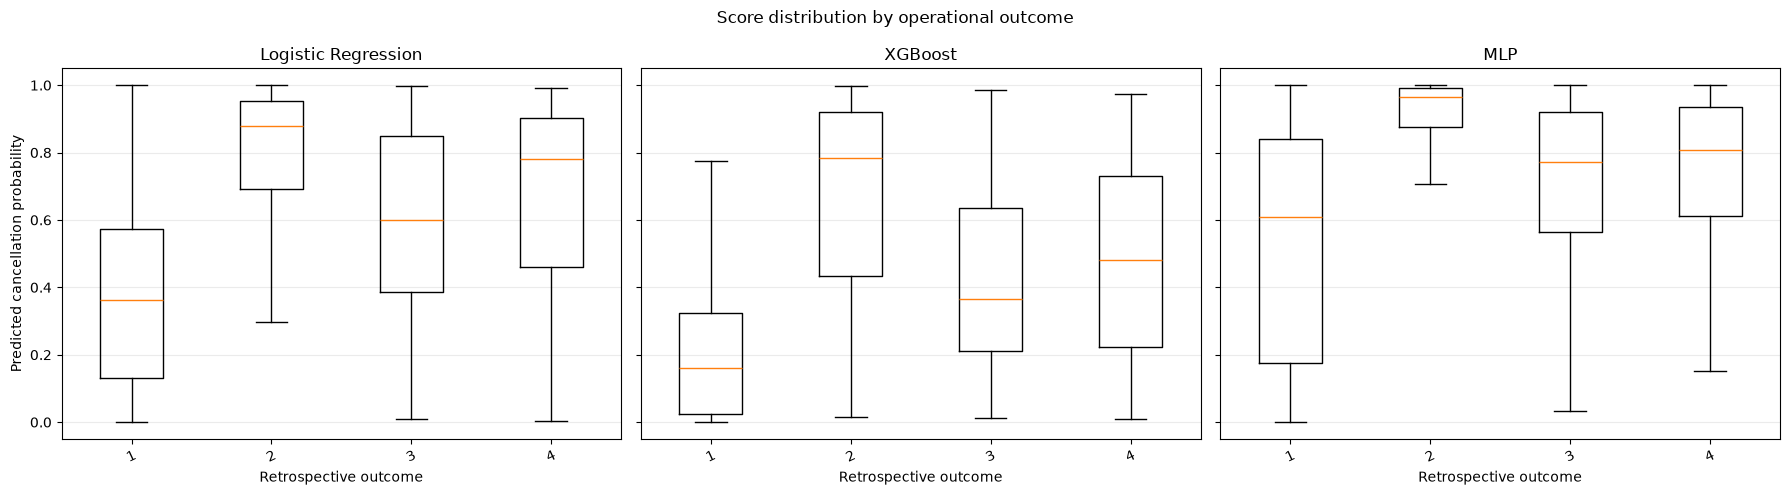

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (model_name, probability_column) in zip(
    axes, MODEL_PROBABILITY_COLUMNS.items()
):
    grouped_scores = [
        operational_holdout.loc[
            operational_holdout["OperationalOutcome"].eq(outcome),
            probability_column,
        ].to_numpy()
        for outcome in OUTCOME_ORDER
    ]
    ax.boxplot(grouped_scores, label=OUTCOME_ORDER, showfliers=False)
    ax.set_title(model_name)
    ax.set_xlabel("Retrospective outcome")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Predicted cancellation probability")
fig.suptitle("Score distribution by operational outcome")
plt.tight_layout()
plt.show()


## Conclusiones diagnósticas

Los tres modelos conservan buen ROC AUC para cancelación general, pero pierden capacidad al evaluar retrospectivamente `IsCriticalCancellation`: Logistic Regression obtiene 0,565019, XGBoost 0,563477 y MLP 0,497290. Entre las reservas que efectivamente cancelaron, los ROC AUC caen a 0,293529, 0,251317 y 0,219339, respectivamente. Los valores inferiores a 0,5 indican que los scores tienden a ordenar por encima las cancelaciones no críticas.

Las distribuciones confirman el desalineamiento. Por ejemplo, XGBoost asigna una mediana de 0,7830 a cancelaciones no críticas, frente a 0,3664 para cancelaciones tardías y 0,4803 para No-Show. Por eso el mejor ranking técnico para `Cancelled` no concentra los eventos económicamente más sensibles en sus primeros percentiles.

El proyecto mantiene `Cancelled` como objetivo original y limita las conclusiones económicas a lo que estos scores realmente permiten. Se propone como trabajo futuro repetir el ciclo de modelado utilizando `IsCriticalCancellation` como target, con las mismas precauciones de disponibilidad temporal y validación.


## Escenarios económicos

El valor bruto de una reserva no se interpreta como pérdida. Para cada evento crítico se estima primero una exposición económica como `GrossBookingValue × contribution_margin × unrecovered_fraction`. La fracción no recuperada se define por separado para No-Show y cancelaciones tardías.

La intervención tampoco se supone capaz de evitar necesariamente la cancelación: `loss_reduction_fraction` representa la proporción de esa pérdida que podría reducir mediante confirmación, garantía de pago, prepago, cancelación anticipada o reventa del inventario. Todos los valores siguientes son supuestos editables para análisis de sensibilidad, no cantidades observadas en el dataset.

El escenario conservador combina menor margen, menor pérdida no recuperada, menor efecto de la intervención y mayor costo de contacto. El escenario favorable extremo representa el límite optimista. El daño adicional por falso positivo se mantiene inicialmente en cero porque el dataset no permite estimar descuentos innecesarios, fricción ni cancelaciones inducidas por el contacto. Se conserva como parámetro explícito para no omitir conceptualmente ese riesgo.


In [23]:
BUSINESS_SCENARIOS = {
    "Conservative": {
        "contribution_margin": 0.50,
        "no_show_unrecovered_fraction": 0.70,
        "late_cancellation_unrecovered_fraction": 0.25,
        "loss_reduction_fraction": 0.10,
        "cost_per_contact": 10.0,
        "false_positive_extra_cost": 0.0,
    },
    "Intermediate": {
        "contribution_margin": 0.70,
        "no_show_unrecovered_fraction": 0.90,
        "late_cancellation_unrecovered_fraction": 0.50,
        "loss_reduction_fraction": 0.30,
        "cost_per_contact": 5.0,
        "false_positive_extra_cost": 0.0,
    },
    "Favorable extreme": {
        "contribution_margin": 0.85,
        "no_show_unrecovered_fraction": 1.00,
        "late_cancellation_unrecovered_fraction": 0.75,
        "loss_reduction_fraction": 0.50,
        "cost_per_contact": 2.0,
        "false_positive_extra_cost": 0.0,
    },
}

business_scenarios = (
    pd.DataFrame.from_dict(BUSINESS_SCENARIOS, orient="index")
    .rename_axis("scenario")
    .reset_index()
)
display(business_scenarios)


,scenario,contribution_margin,no_show_unrecovered_fraction,late_cancellation_unrecovered_fraction,loss_reduction_fraction,cost_per_contact,false_positive_extra_cost
0,Conservative,0.50,0.7,0.25,0.1,10.0,0.0
1,Intermediate,0.70,0.9,0.50,0.3,5.0,0.0
2,Favorable extreme,0.85,1.0,0.75,0.5,2.0,0.0


## Cálculo económico por política

Para cada escenario se calcula la pérdida estimada sin actuar sobre todos los eventos críticos. Luego, para cada modelo y capacidad, se suma la pérdida correspondiente a los eventos críticos seleccionados y se aplica la reducción supuesta. A ese beneficio se restan el costo de todos los contactos y el posible daño adicional de las intervenciones no críticas.

`net_savings = recoverable_benefit - contact_cost - false_positive_cost`. La efectividad de equilibrio indica qué fracción de la pérdida detectada debería reducir la intervención para cubrir sus costos. Un valor superior a uno significa que la política no puede alcanzar el equilibrio bajo esos supuestos, incluso reduciendo toda la pérdida detectada.


In [24]:
FRACTION_PARAMETERS = [
    "contribution_margin",
    "no_show_unrecovered_fraction",
    "late_cancellation_unrecovered_fraction",
    "loss_reduction_fraction",
]


def validate_business_scenario(parameters):
    missing = set(FRACTION_PARAMETERS + [
        "cost_per_contact", "false_positive_extra_cost"
    ]).difference(parameters)
    if missing:
        raise ValueError(f"Missing business parameters: {sorted(missing)}")
    for parameter in FRACTION_PARAMETERS:
        if not 0 <= parameters[parameter] <= 1:
            raise ValueError(f"{parameter} must be between 0 and 1.")
    for parameter in ["cost_per_contact", "false_positive_extra_cost"]:
        if parameters[parameter] < 0:
            raise ValueError(f"{parameter} cannot be negative.")


def estimate_event_loss(frame, parameters):
    validate_business_scenario(parameters)
    unrecovered_fraction = np.select(
        [frame["IsNoShow"], frame["IsLateCancellation"]],
        [
            parameters["no_show_unrecovered_fraction"],
            parameters["late_cancellation_unrecovered_fraction"],
        ],
        default=0.0,
    )
    return (
        frame["GrossBookingValue"].fillna(0.0)
        * parameters["contribution_margin"]
        * unrecovered_fraction
    )


def evaluate_economic_policy(frame, selected_mask, scenario_name, parameters, model_name, capacity):
    selected_mask = pd.Series(selected_mask, index=frame.index).astype(bool)
    event_loss = estimate_event_loss(frame, parameters)
    critical_mask = frame["IsCriticalCancellation"]
    non_critical_interventions = int((selected_mask & ~critical_mask).sum())
    detected_loss = event_loss.loc[selected_mask & critical_mask].sum()
    no_action_loss = event_loss.sum()
    recoverable_benefit = detected_loss * parameters["loss_reduction_fraction"]
    contact_cost = selected_mask.sum() * parameters["cost_per_contact"]
    false_positive_cost = (
        non_critical_interventions * parameters["false_positive_extra_cost"]
    )
    total_policy_cost = contact_cost + false_positive_cost
    net_savings = recoverable_benefit - total_policy_cost

    return {
        "scenario": scenario_name,
        "model": model_name,
        "capacity": capacity,
        "interventions": int(selected_mask.sum()),
        "non_critical_interventions": non_critical_interventions,
        "no_action_estimated_loss": no_action_loss,
        "detected_estimated_loss": detected_loss,
        "recoverable_benefit": recoverable_benefit,
        "contact_cost": contact_cost,
        "false_positive_cost": false_positive_cost,
        "net_savings": net_savings,
        "relative_net_savings": (
            net_savings / no_action_loss if no_action_loss else np.nan
        ),
        "break_even_loss_reduction": (
            total_policy_cost / detected_loss if detected_loss else np.inf
        ),
    }


In [25]:
economic_rows = []
for scenario_name, parameters in BUSINESS_SCENARIOS.items():
    for model_name, probability_column in MODEL_PROBABILITY_COLUMNS.items():
        scores = operational_holdout[probability_column]
        for capacity_rate in CAPACITY_RATES:
            intervention_count = int(np.ceil(capacity_rate * len(operational_holdout)))
            selected_indices = scores.nlargest(intervention_count, keep="first").index
            selected_mask = operational_holdout.index.isin(selected_indices)
            economic_rows.append(evaluate_economic_policy(
                operational_holdout,
                selected_mask,
                scenario_name=scenario_name,
                parameters=parameters,
                model_name=model_name,
                capacity=capacity_rate,
            ))

economic_results = pd.DataFrame(economic_rows)
display(economic_results.round(4))


,scenario,model,capacity,interventions,non_critical_interventions,no_action_estimated_loss,detected_estimated_loss,recoverable_benefit,contact_cost,false_positive_cost,net_savings,relative_net_savings,break_even_loss_reduction
0,Conservative,Logistic Regression,0.05,2035,1967,94720.2860,7662.3068,766.2307,20350.0,0.0,-19583.7693,-0.2068,2.6559
1,Conservative,Logistic Regression,0.10,4069,3954,94720.2860,11474.0445,1147.4044,40690.0,0.0,-39542.5956,-0.4175,3.5463
2,Conservative,Logistic Regression,0.20,8138,7806,94720.2860,26776.7065,2677.6706,81380.0,0.0,-78702.3294,-0.8309,3.0392
3,Conservative,Logistic Regression,0.30,12207,11687,94720.2860,39348.1710,3934.8171,122070.0,0.0,-118135.1829,-1.2472,3.1023
4,Conservative,XGBoost,0.05,2035,2031,94720.2860,1132.2812,113.2281,20350.0,0.0,-20236.7719,-0.2136,17.9726
5,Conservative,XGBoost,0.10,4069,4012,94720.2860,7051.8035,705.1804,40690.0,0.0,-39984.8196,-0.4221,5.7702
6,Conservative,XGBoost,0.20,8138,7948,94720.2860,19908.9148,1990.8915,81380.0,0.0,-79389.1085,-0.8381,4.0876
7,Conservative,XGBoost,0.30,12207,11766,94720.2860,34919.6158,3491.9616,122070.0,0.0,-118578.0384,-1.2519,3.4957
8,Conservative,MLP,0.05,2035,2020,94720.2860,4012.9892,401.2989,20350.0,0.0,-19948.7011,-0.2106,5.0710
9,Conservative,MLP,0.10,4069,4013,94720.2860,7890.2918,789.0292,40690.0,0.0,-39900.9708,-0.4213,5.1570


## Lectura resumida de los escenarios

La tabla siguiente permite comparar rápidamente el ahorro neto manteniendo separados escenario, modelo y capacidad. Todavía no se utiliza para declarar una política ganadora: primero debe comprobarse qué supuestos producen resultados positivos, si la efectividad de equilibrio es plausible y si la cantidad de contactos es operativamente viable.


In [26]:
net_savings_comparison = economic_results.pivot_table(
    index=["model", "capacity"],
    columns="scenario",
    values="net_savings",
)
display(net_savings_comparison.round(2))


scenario                      Conservative  Favorable extreme  Intermediate
model               capacity                                               
Logistic Regression 0.05         -19583.77           10991.97      -4744.17
                    0.10         -39542.60           13310.12     -12461.08
                    0.20         -78702.33           32835.12     -22503.01
                    0.30        -118135.18           48443.20     -34154.66
MLP                 0.05         -19948.70            4807.05      -7108.66
                    0.10         -39900.97            8741.71     -14444.98
                    0.20         -79331.84           25145.48     -25912.60
                    0.30        -118968.68           37400.91     -38862.45
XGBoost             0.05         -20236.77           -1182.68      -9223.88
                    0.10         -39984.82            4274.58     -15672.39
                    0.20         -79389.11           20049.69     -27210.18
                    0.30        -118578.04           39739.39     -37293.16

## Conclusiones económicas

Ninguna política resulta rentable en los escenarios conservador e intermedio. En el escenario intermedio, Logistic Regression con capacidad de 5 % es la alternativa más cercana al equilibrio: genera un ahorro neto de -4.744,17 unidades y exigiría reducir 56,21 % de la pérdida detectada, frente al 30 % supuesto.

Los ahorros se vuelven positivos principalmente en el escenario favorable extremo. Logistic Regression alcanza 10.991,97 unidades con capacidad de 5 % y 48.443,20 con 30 %, pero esta última política requiere 12.207 contactos. El mayor ahorro monetario no implica automáticamente una política operativamente conveniente.

Logistic Regression presenta el mejor resultado económico entre los modelos comparados, aunque XGBoost conserva el mayor ROC AUC para `Cancelled`. Este contraste confirma que ordenar cancelaciones generales no equivale a priorizar los eventos críticos utilizados en el cálculo económico.

Los resultados favorables siguen siendo optimistas porque el costo adicional por falso positivo se mantiene en cero. Descuentos innecesarios, fricción y cancelaciones inducidas por el contacto reducirían el beneficio, pero no pueden estimarse con este dataset. En consecuencia, la política sólo muestra viabilidad bajo supuestos favorables y no se recomienda como una fuente de ahorro demostrada. Entrenar directamente para `IsCriticalCancellation` queda propuesto como trabajo futuro.
